# Iris Flower Classification
### A Complete Machine Learning Pipeline with Scikit-Learn

---
This notebook walks through a full supervised classification workflow on the classic Iris dataset:

| Step | Description |
|------|-------------|
| 1 | Load & inspect the Iris dataset |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Train/test split |
| 4 | Train Logistic Regression & Random Forest |
| 5 | Evaluate: accuracy, confusion matrix, classification report |
| 6 | Compare model performance |
| 7 | Final summary & findings |

> **Dataset**: 150 iris flower samples, 3 species (Setosa, Versicolor, Virginica), 4 features each.


---
## Step 1: Import Libraries & Load Dataset


In [ ]:
# Standard library
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import importlib.metadata
from typing import cast
from sklearn.utils import Bunch
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

# Scikit-learn: dataset
from sklearn.datasets import load_iris

# Scikit-learn: preprocessing & splitting
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Scikit-learn: classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Scikit-learn: evaluation
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

print('All libraries imported successfully!')
print(f'  NumPy  : {np.__version__}')
print(f'  Pandas : {pd.__version__}')
print(f'  Seaborn: {importlib.metadata.version("seaborn")}')

ModuleNotFoundError: No module named 'numpy'

### Data Source: scikit-learn built-in
> Loading the iris dataset directly from sklearn avoids extra environment dependencies.


In [ ]:
# Load Iris dataset from scikit-learn built-in source.
_iris = cast(Bunch, load_iris())
df = pd.DataFrame(data=_iris.data, columns=_iris.feature_names)
df.columns = ["sepal_length","sepal_width","petal_length","petal_width"]
df["species_id"] = _iris.target
df["species_name"] = pd.Categorical([_iris.target_names[i] for i in _iris.target])
CLASS_NAMES = list(_iris.target_names)
DATA_SOURCE = "scikit-learn built-in"

print(f"Data source   : {DATA_SOURCE}")
print(f"Dataset shape : {df.shape}")
print(f"Target classes: {CLASS_NAMES}")
df.head(10)

First 5 records:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
Data source   : Kaggle (saurabh00007/iriscsv)
Dataset shape : (150, 6)
Target classes: ['setosa', 'versicolor', 'virginica']


,sepal_length,sepal_width,petal_length,petal_width,species_name,species_id
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0
5,5.4,3.9,1.7,0.4,setosa,0
6,4.6,3.4,1.4,0.3,setosa,0
7,5.0,3.4,1.5,0.2,setosa,0
8,4.4,2.9,1.4,0.2,setosa,0
9,4.9,3.1,1.5,0.1,setosa,0


---
## Step 2: Exploratory Data Analysis (EDA)


In [ ]:
# 2.1  Basic statistics
# Understanding spread and data quality is the mandatory first EDA step.
features = ['sepal_length','sepal_width','petal_length','petal_width']

print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Descriptive Statistics ===')
df[features].describe().round(2)


=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   sepal_length  150 non-null    float64 
 1   sepal_width   150 non-null    float64 
 2   petal_length  150 non-null    float64 
 3   petal_width   150 non-null    float64 
 4   species_name  150 non-null    category
 5   species_id    150 non-null    int64   
dtypes: category(1), float64(4), int64(1)
memory usage: 6.2 KB

=== Missing Values ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species_name    0
species_id      0
dtype: int64

=== Descriptive Statistics ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


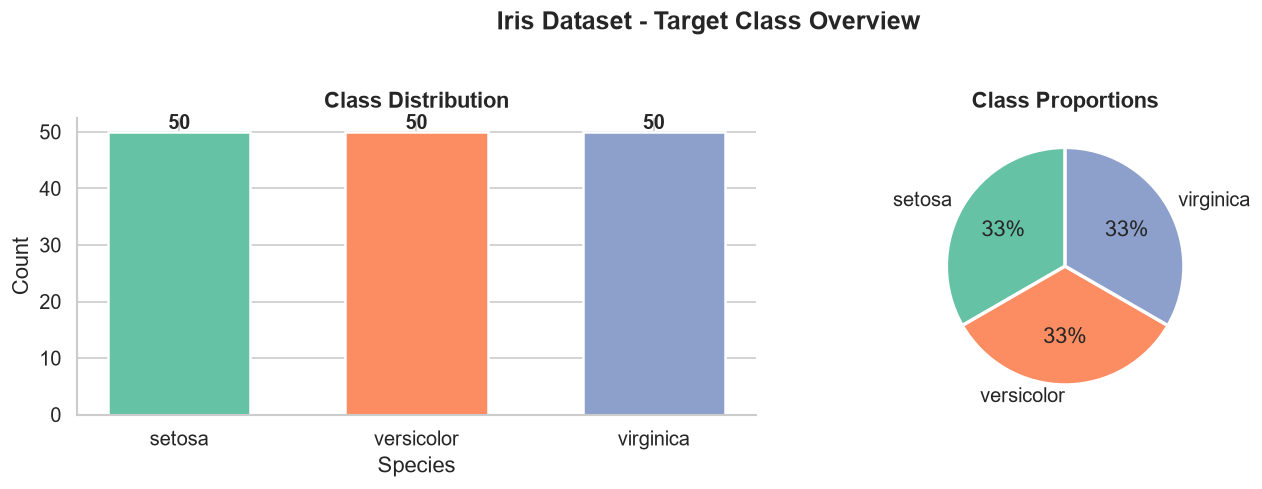

Perfectly balanced: 50 samples per class.


In [ ]:
# 2.2  Class distribution
# Balanced classes -> accuracy is a fair metric here.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts  = df['species_name'].value_counts()
palette = sns.color_palette('Set2', 3)

axes[0].bar(counts.index, counts.values, color=palette, edgecolor='white', linewidth=1.5, width=0.6)
axes[0].set_title('Class Distribution', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Species'); axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].pie(counts.values, labels=counts.index, colors=palette, autopct='%1.0f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportions', fontweight='bold', fontsize=13)

plt.suptitle('Iris Dataset - Target Class Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Perfectly balanced: 50 samples per class.')


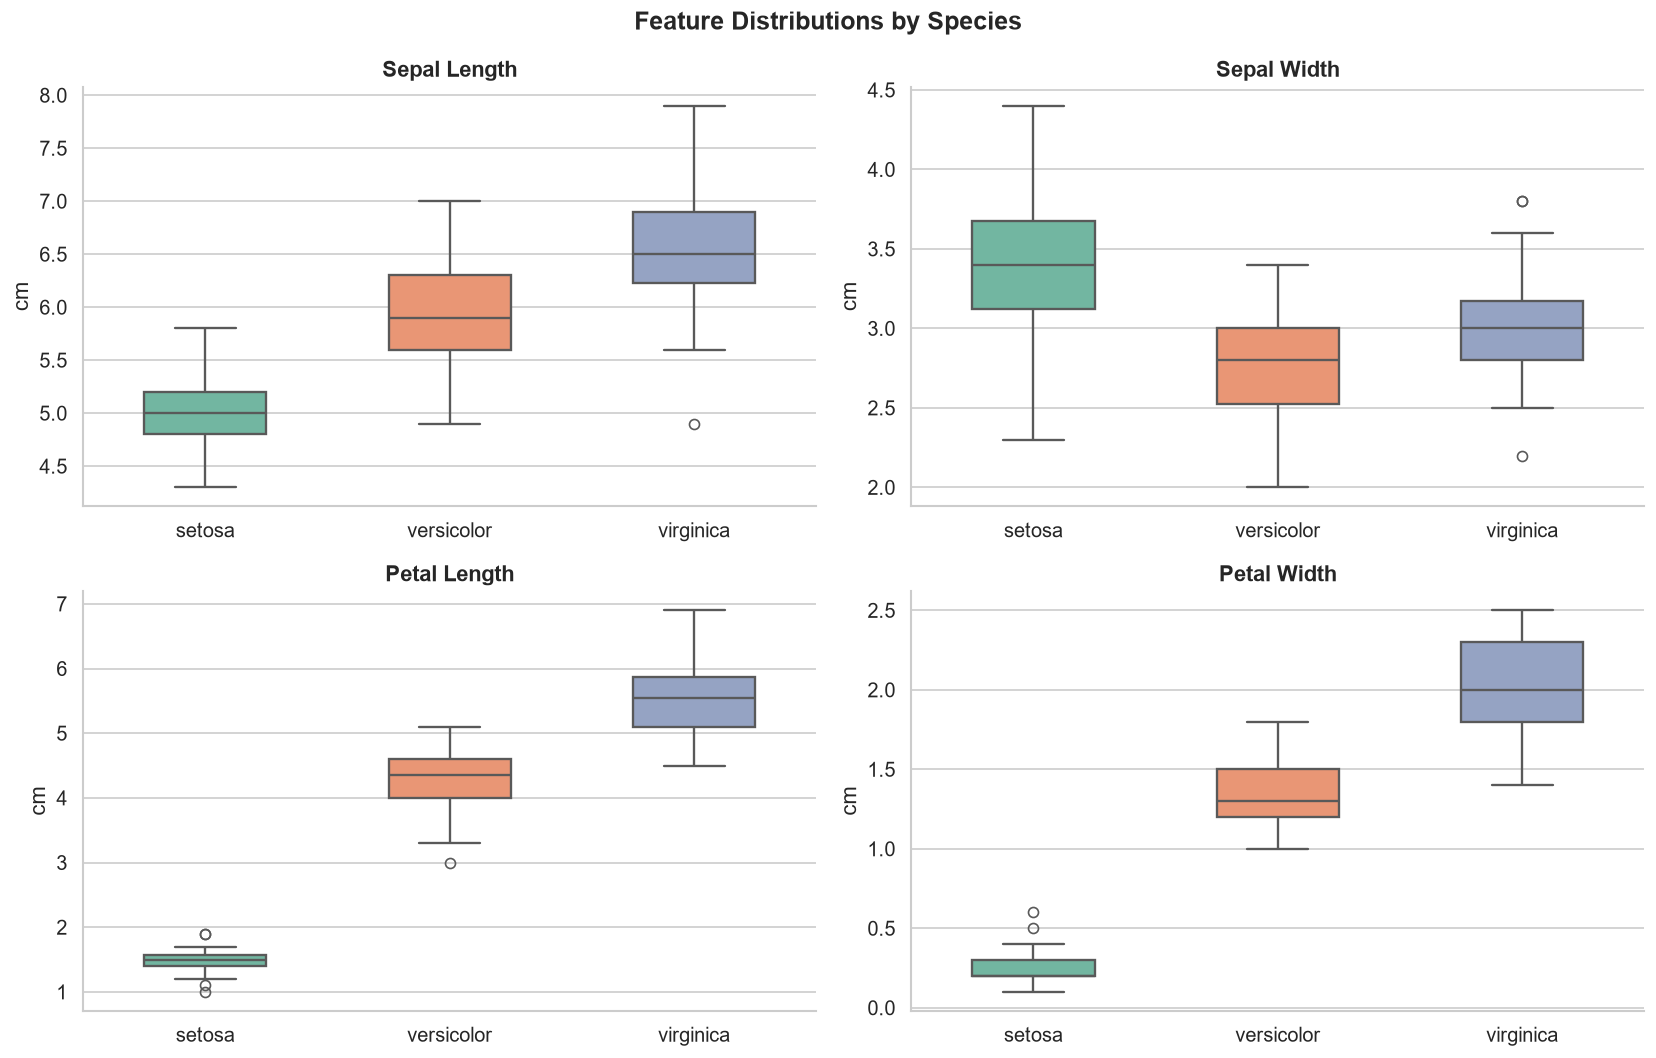

In [ ]:
# 2.3  Box plots
# Median, IQR, and outliers for each feature separated by species.

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()
for ax, feat in zip(axes, features):
    sns.boxplot(data=df, x='species_name', y=feat, palette='Set2', width=0.5, ax=ax, linewidth=1.4)
    ax.set_title(feat.replace('_',' ').title(), fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('cm')

plt.suptitle('Feature Distributions by Species', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight', dpi=150)
plt.show()


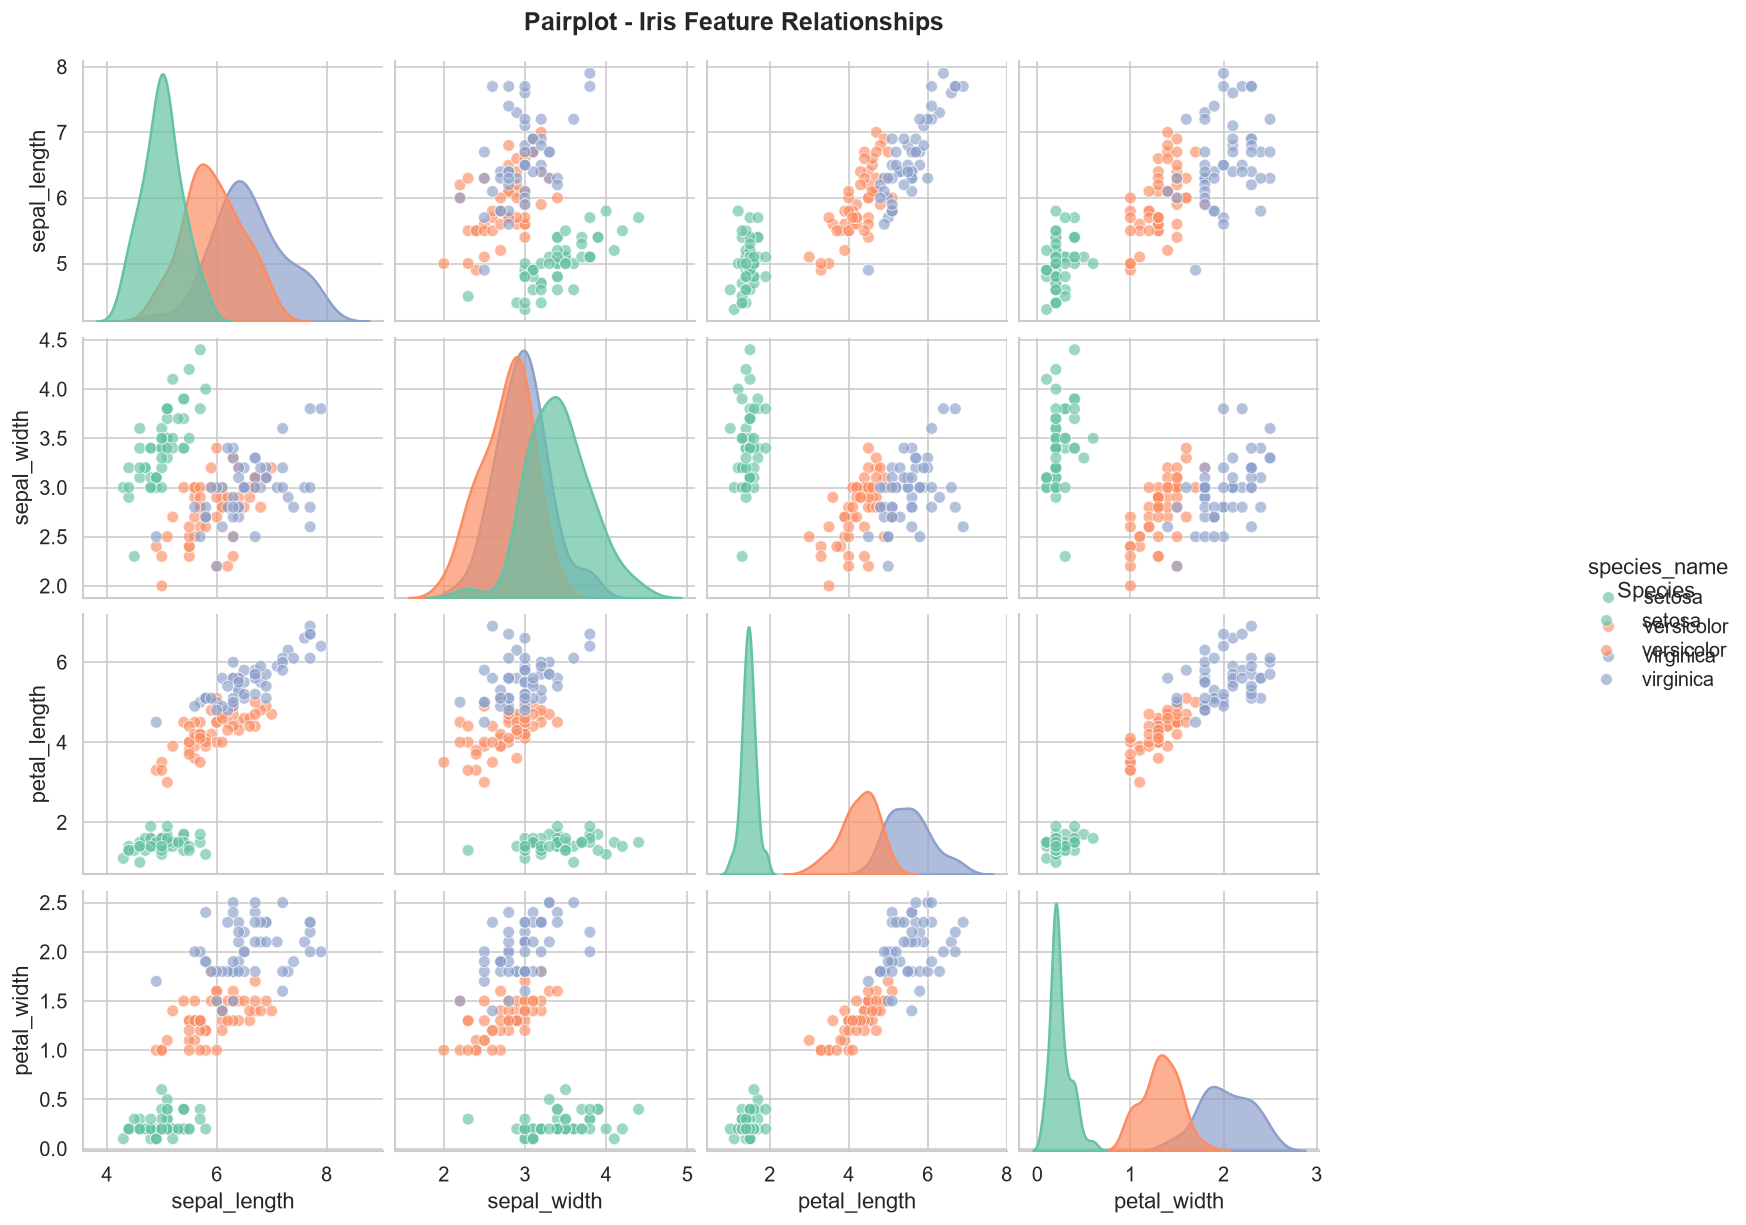

Setosa is linearly separable from the others.
Versicolor and Virginica overlap slightly in sepal features.


In [ ]:
# 2.4  Pairplot
# Shows pairwise scatter plots and per-class KDE on the diagonal.
# One of the most informative plots for multi-class classification tasks.

pp = sns.pairplot(
    df, hue='species_name', vars=features,
    diag_kind='kde',
    plot_kws=dict(alpha=0.65, edgecolors='white', s=50),
    diag_kws=dict(alpha=0.7, linewidth=1.5),
    palette='Set2'
)
pp.fig.suptitle('Pairplot - Iris Feature Relationships', y=1.02, fontsize=15, fontweight='bold')
pp.add_legend(title='Species', bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.savefig('pairplot.png', bbox_inches='tight', dpi=120)
plt.show()

print('Setosa is linearly separable from the others.')
print('Versicolor and Virginica overlap slightly in sepal features.')


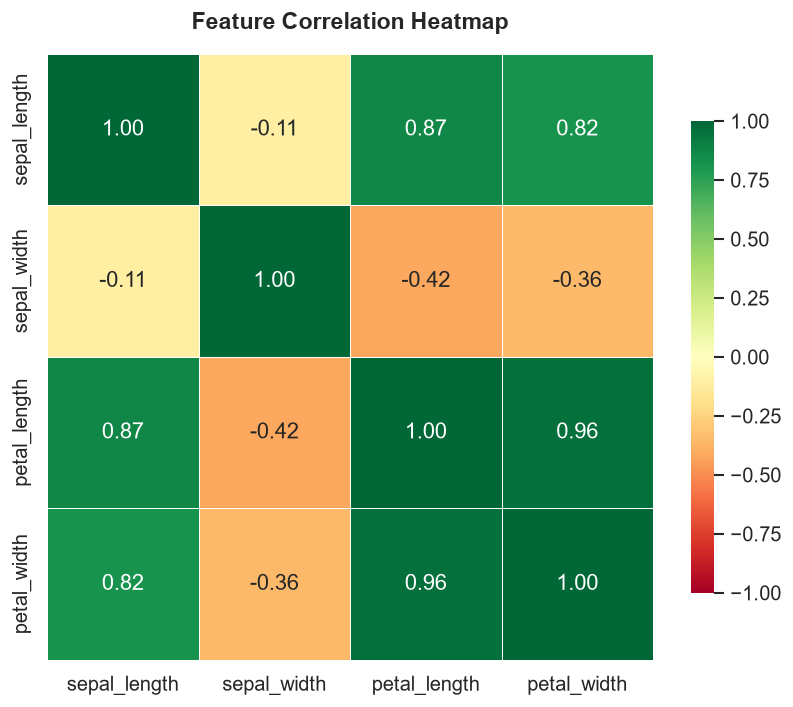

petal_length and petal_width are highly correlated (r ~ 0.96).
sepal_width is negatively correlated with petal features.


In [ ]:
# 2.5  Correlation Heatmap
# Quantifies linear relationships between features.
# High correlation can indicate multicollinearity.

corr = df[features].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, square=True, linewidths=0.5,
    linecolor='white', cbar_kws=dict(shrink=0.75), ax=ax
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

print('petal_length and petal_width are highly correlated (r ~ 0.96).')
print('sepal_width is negatively correlated with petal features.')


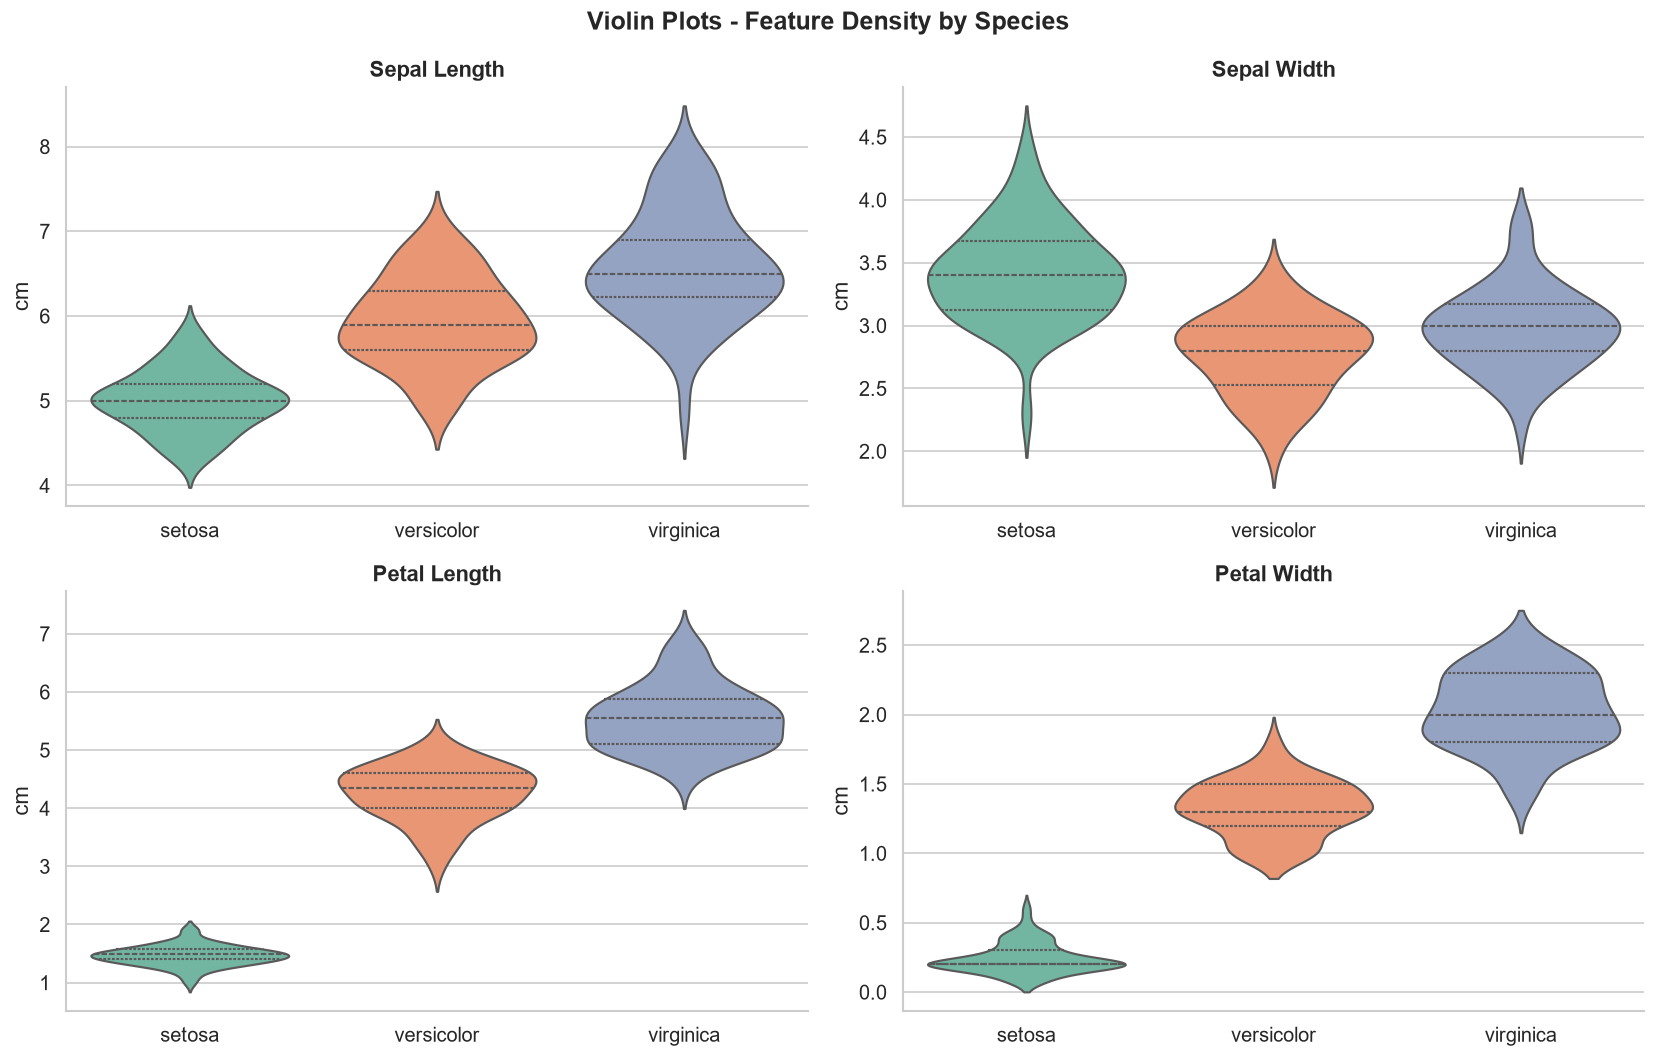

In [ ]:
# 2.6  Violin plots
# Combines box-plot stats with KDE for richer distributional insight.

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()
for ax, feat in zip(axes, features):
    sns.violinplot(data=df, x='species_name', y=feat, palette='Set2',
                   inner='quartile', linewidth=1.3, ax=ax)
    ax.set_title(feat.replace('_',' ').title(), fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('cm')

plt.suptitle('Violin Plots - Feature Density by Species', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('violin_plots.png', bbox_inches='tight', dpi=150)
plt.show()


---
## Step 3: Prepare Features & Split Data


In [ ]:
# 3.1  Extract Feature Matrix & Target Vector
# Prepare X (features) and y (target) for model training.

X: np.ndarray = df[features].values
y: np.ndarray = df['species_id'].values
CLASS_NAMES = ['Setosa', 'Versicolor', 'Virginica']

print(f'Features: {features}')
print(f'Target  : species_id (0=Setosa, 1=Versicolor, 2=Virginica)')

In [ ]:
print(f'Feature matrix shape : {X.shape}')
print(f'Target vector shape  : {y.shape}')
print(f'Class labels         : {np.unique(y)} -> {list(CLASS_NAMES)}')  # type: ignore

Feature matrix shape : (150, 4)
Target vector shape  : (150,)
Class labels         : [0 1 2] -> ['setosa', 'versicolor', 'virginica']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y  # type: ignore
)

print(f'Training set   : {X_train.shape[0]} samples')
print(f'Test set       : {X_test.shape[0]}  samples')
print(f'Train class distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}')  # type: ignore
print(f'Test  class distribution: {dict(zip(*np.unique(y_test,  return_counts=True)))}')  # type: ignore

Training set   : 120 samples
Test set       : 30  samples
Train class distribution: {np.int64(0): np.int64(40), np.int64(1): np.int64(40), np.int64(2): np.int64(40)}
Test  class distribution: {np.int64(0): np.int64(10), np.int64(1): np.int64(10), np.int64(2): np.int64(10)}


In [ ]:
# 3.3  Feature Scaling (StandardScaler)
# Logistic Regression and distance-based models are sensitive to feature scale.
# Standardise: x' = (x - mean) / std.
# IMPORTANT: fit ONLY on training data to prevent data leakage.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
X_test_scaled  = scaler.transform(X_test)        # transform only

print('Features scaled to zero mean, unit variance.')
print(f'  Train mean (post-scale): {X_train_scaled.mean(axis=0).round(6)}')
print(f'  Train std  (post-scale): {X_train_scaled.std(axis=0).round(6)}')


Features scaled to zero mean, unit variance.
  Train mean (post-scale): [-0. -0.  0.  0.]
  Train std  (post-scale): [1. 1. 1. 1.]


---
## Step 4: Train Classifiers


In [ ]:
# 4.1  Evaluation helper
# Encapsulates cross-validation + test evaluation to keep code DRY.

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, n_splits=5):
    """Train model, run stratified k-fold CV, evaluate on test set."""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='accuracy')
    model.fit(X_tr, y_tr)
    y_pred   = model.predict(X_te)
    test_acc = accuracy_score(y_te, y_pred)

    print(f'\n{chr(9472)*55}')
    print(f'  Model      : {name}')
    print(f'  CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
    print(f'  Test Acc   : {test_acc:.4f}')
    print(f'{chr(9472)*55}')

    return {'name': name, 'model': model, 'y_pred': y_pred,
            'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
            'test_acc': test_acc, 'cv_scores': cv_scores}

results = {}
print('Evaluation helper ready.')


Evaluation helper ready.


In [ ]:
# 4.2  Model 1: Logistic Regression
# Linear probabilistic classifier. Trained on SCALED data.
# C=1.0 controls regularisation strength (higher = less regularised).

lr = LogisticRegression(max_iter=1000, solver='lbfgs',
                         random_state=42, C=1.0)
results['Logistic Regression'] = evaluate_model(
    'Logistic Regression', lr,
    X_train_scaled, y_train, X_test_scaled, y_test
)



───────────────────────────────────────────────────────
  Model      : Logistic Regression
  CV Accuracy: 0.9583 +/- 0.0264
  Test Acc   : 0.9333
───────────────────────────────────────────────────────


In [ ]:
# 4.3  Model 2: Random Forest
# Ensemble of 200 decision trees. Scale-invariant (no scaling needed).
# Provides Gini-impurity based feature importances.

rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                             random_state=42, n_jobs=-1)
results['Random Forest'] = evaluate_model(
    'Random Forest', rf,
    X_train, y_train, X_test, y_test  # raw unscaled data
)



───────────────────────────────────────────────────────
  Model      : Random Forest
  CV Accuracy: 0.9500 +/- 0.0312
  Test Acc   : 0.9000
───────────────────────────────────────────────────────


In [ ]:
# 4.4  Bonus Model 3: Support Vector Machine (RBF kernel)
# Finds the maximum-margin hyperplane in a kernel-mapped feature space.
# Excellent for small, well-structured datasets.

svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
results['SVM (RBF)'] = evaluate_model(
    'SVM (RBF)', svm,
    X_train_scaled, y_train, X_test_scaled, y_test
)



───────────────────────────────────────────────────────
  Model      : SVM (RBF)
  CV Accuracy: 0.9667 +/- 0.0167
  Test Acc   : 0.9667
───────────────────────────────────────────────────────


In [ ]:
# 4.5  Bonus Model 4: k-Nearest Neighbours
# Non-parametric; classifies by majority vote among k neighbours.
# Simple and interpretable but sensitive to feature scale.

knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
results['k-NN (k=5)'] = evaluate_model(
    'k-NN (k=5)', knn,
    X_train_scaled, y_train, X_test_scaled, y_test
)



───────────────────────────────────────────────────────
  Model      : k-NN (k=5)
  CV Accuracy: 0.9583 +/- 0.0264
  Test Acc   : 0.9333
───────────────────────────────────────────────────────


---
## Step 5: Evaluate Each Model in Detail


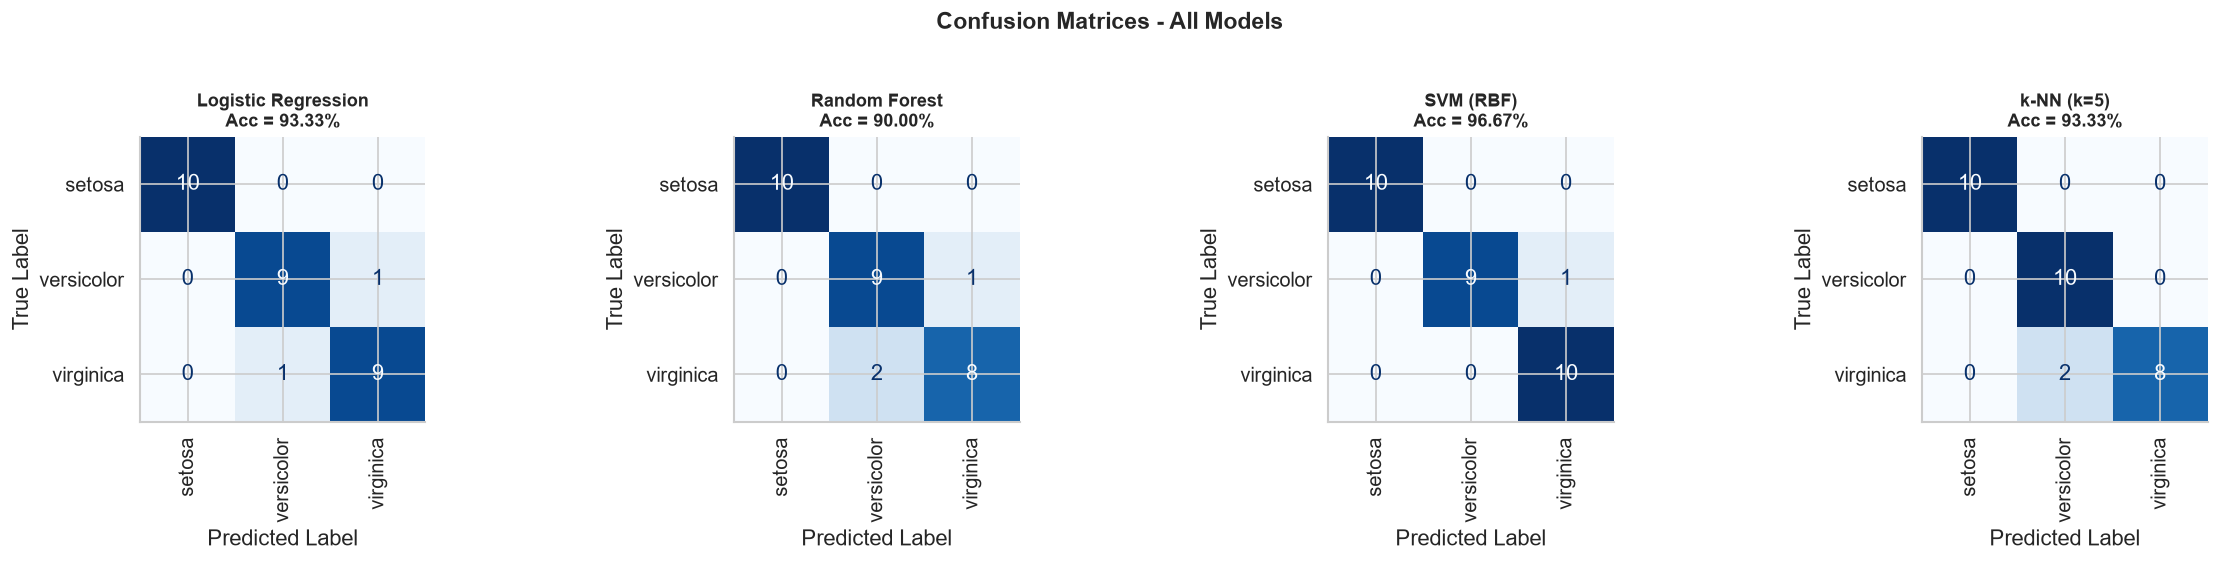

In [ ]:
# 5.1  Confusion Matrices
# Actual vs predicted class grid. Off-diagonal = misclassifications.

class_names = CLASS_NAMES
n_models    = len(results)
fig, axes   = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
if n_models == 1: axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm   = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation='vertical')
    ax.set_title(f"{name}\nAcc = {res['test_acc']:.2%}", fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
# 5.2  Classification Reports
# Per-class precision, recall, and F1-score.
#   Precision = TP/(TP+FP)  -> how many predicted positives are correct?
#   Recall    = TP/(TP+FN)  -> how many actual positives were found?
#   F1-score  = harmonic mean of precision and recall

for name, res in results.items():
    print(f'\n{chr(9552)*55}')
    print(f'  Classification Report: {name}')
    print(f'{chr(9552)*55}')
    print(classification_report(y_test, res['y_pred'], target_names=class_names))



═══════════════════════════════════════════════════════
  Classification Report: Logistic Regression
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


═══════════════════════════════════════════════════════
  Classification Report: Random Forest
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90    

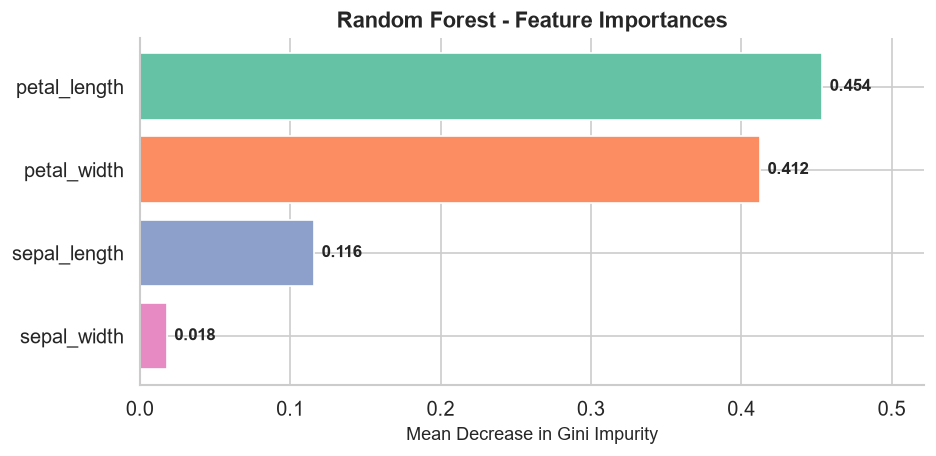

petal_length and petal_width are the strongest predictors.


In [ ]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors  = sns.color_palette('Set2', len(features))
bars    = ax.barh(importances.index, importances.values, color=colors[::-1], edgecolor='white')  # type: ignore
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Mean Decrease in Gini Impurity', fontsize=11)
ax.set_title('Random Forest - Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlim(0, importances.max() * 1.15)
plt.tight_layout()
plt.savefig('feature_importances.png', bbox_inches='tight', dpi=150)
plt.show()
print('petal_length and petal_width are the strongest predictors.')

---
## Step 6: Compare Model Performance


In [ ]:
# 6.1  Summary DataFrame
# Aggregate all metrics into a tidy comparison table.

summary = pd.DataFrame([
    {'Model': name,
     'CV Accuracy': round(res['cv_mean'], 4),
     'CV Std':      round(res['cv_std'],  4),
     'Test Accuracy': round(res['test_acc'], 4)}
    for name, res in results.items()
]).set_index('Model')

print('Model Comparison Summary')
print('='*55)
print(summary.to_string())
print('='*55)

best = max(results.items(), key=lambda x: x[1]['test_acc'])
print(f"Best model: {best[0]} | Test accuracy = {best[1]['test_acc']:.2%}")


Model Comparison Summary
                     CV Accuracy  CV Std  Test Accuracy
Model                                                  
Logistic Regression       0.9583  0.0264         0.9333
Random Forest             0.9500  0.0312         0.9000
SVM (RBF)                 0.9667  0.0167         0.9667
k-NN (k=5)                0.9583  0.0264         0.9333
Best model: SVM (RBF) | Test accuracy = 96.67%


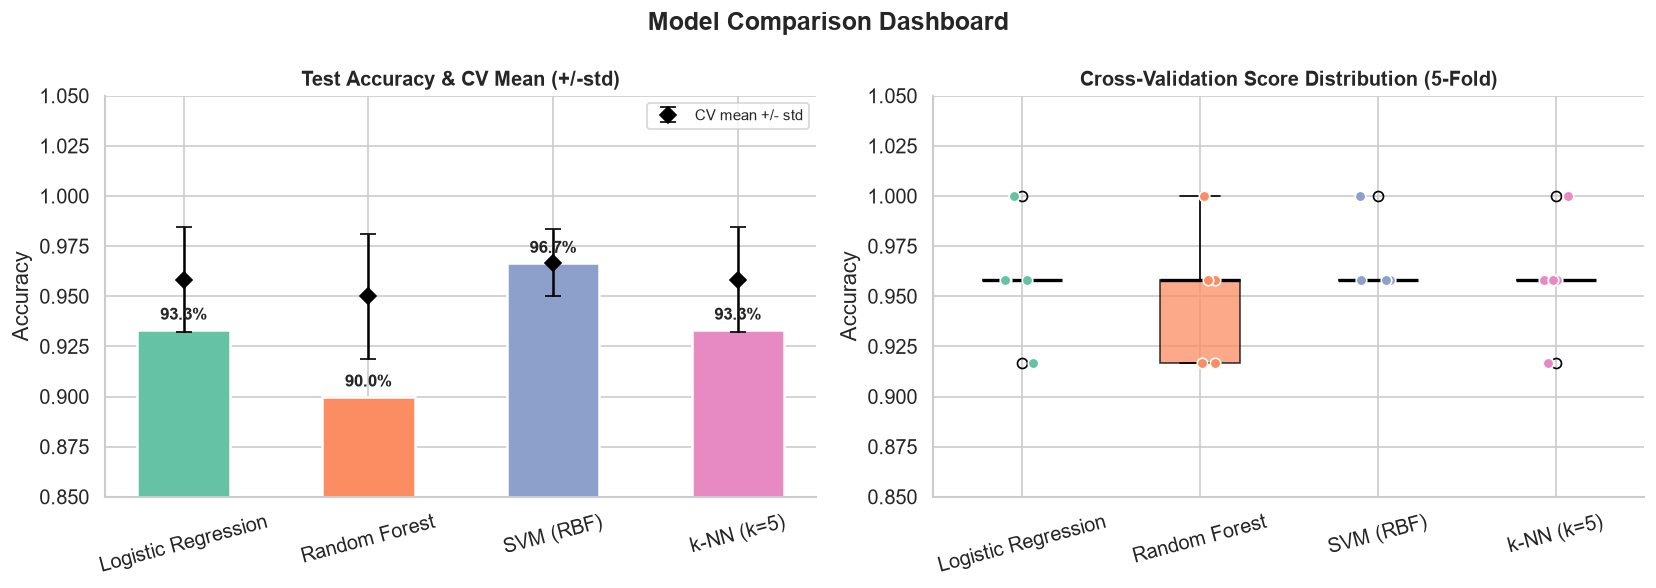

In [ ]:
# 6.2  Visual Model Comparison
# (a) Test accuracy bar chart with CV mean/std overlay
# (b) Cross-validation score distribution box plot

model_names = list(results.keys())
test_accs   = [res['test_acc']  for res in results.values()]
cv_means    = [res['cv_mean']   for res in results.values()]
cv_stds     = [res['cv_std']    for res in results.values()]
all_cv      = [res['cv_scores'] for res in results.values()]
palette     = sns.color_palette('Set2', len(model_names))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Bar chart
bars = axes[0].bar(model_names, test_accs, color=palette, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].errorbar(model_names, cv_means, yerr=cv_stds, fmt='D', color='black',
                  markersize=7, capsize=5, label='CV mean +/- std')
for bar, acc in zip(bars, test_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{acc:.1%}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_ylim(0.85, 1.05)
axes[0].set_title('Test Accuracy & CV Mean (+/-std)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Accuracy'); axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

# (b) Box plot of cross-validation fold scores
bp = axes[1].boxplot(all_cv, tick_labels=model_names, patch_artist=True, widths=0.45,
                      medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color); patch.set_alpha(0.75)

rng = np.random.default_rng(0)
for i, (cv, color) in enumerate(zip(all_cv, palette), start=1):
    jitter = rng.uniform(-0.1, 0.1, len(cv))
    axes[1].scatter(np.full_like(cv, i) + jitter, cv, color=color, s=40, zorder=5, edgecolors='white')

axes[1].set_title('Cross-Validation Score Distribution (5-Fold)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Accuracy'); axes[1].set_ylim(0.85, 1.05)
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison Dashboard', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


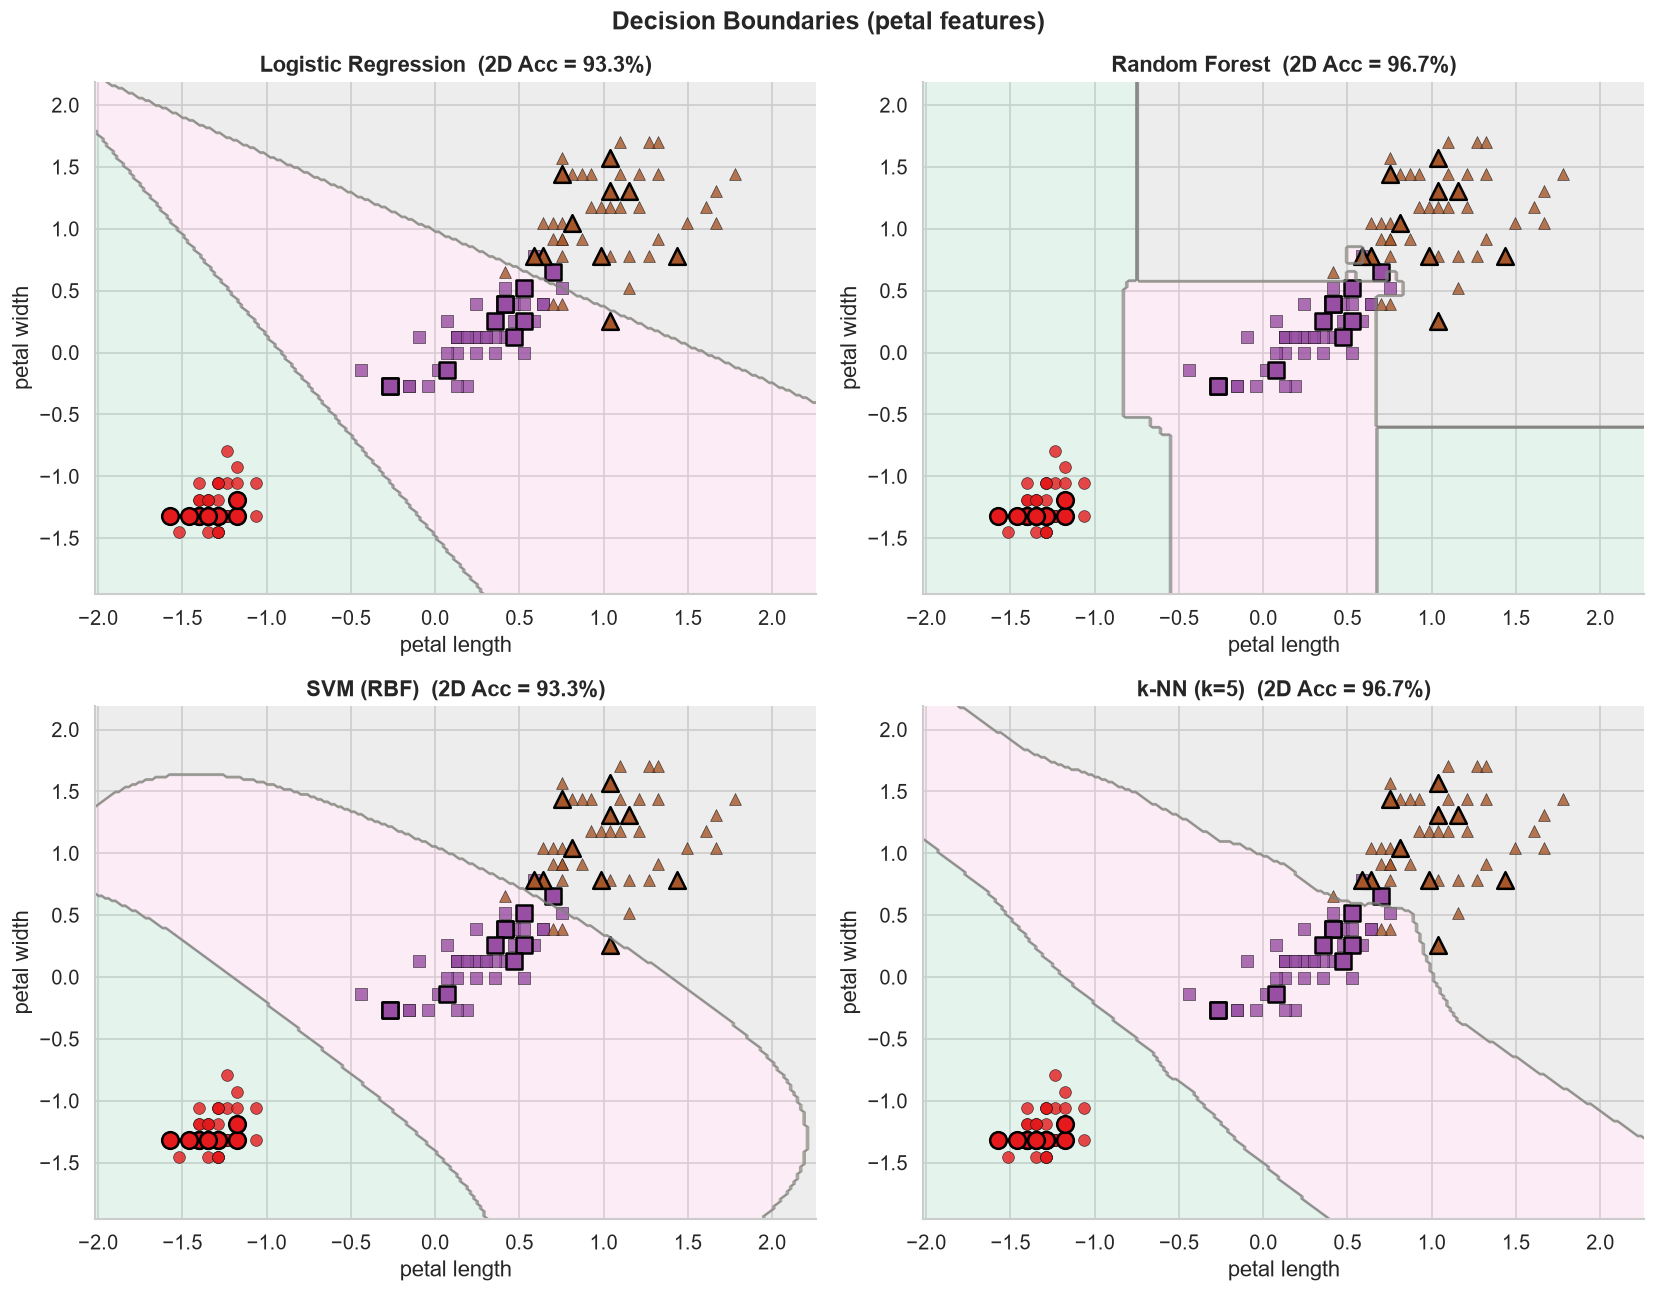

In [ ]:
# 6.3  Decision Boundary Visualisation (2D projection)
# Reduce to the two most informative features (petal_length, petal_width)
# and plot each classifier's decision boundary in 2D space.

feat_idx    = [2, 3]  # petal_length, petal_width
feat_labels = [features[i] for i in feat_idx]
X2_train    = X_train_scaled[:, feat_idx]
X2_test     = X_test_scaled[:, feat_idx]

models_2d = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM (RBF)'          : SVC(kernel='rbf', gamma='scale', random_state=42),
    'k-NN (k=5)'         : KNeighborsClassifier(n_neighbors=5),
}

h = 0.02
x_min, x_max = X2_train[:,0].min()-0.5, X2_train[:,0].max()+0.5
y_min, y_max = X2_train[:,1].min()-0.5, X2_train[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.ravel()

for ax, (name, mdl) in zip(axes, models_2d.items()):
    mdl.fit(X2_train, y_train)
    Z = mdl.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap='Pastel2')
    ax.contour(xx, yy, Z, colors='grey', linewidths=0.7, alpha=0.6)
    cmap = plt.get_cmap('Set1')
    for cls, marker in zip([0,1,2], ['o','s','^']):
        c = cmap(cls/3)
        ax.scatter(X2_train[y_train==cls,0], X2_train[y_train==cls,1],
                   c=[c], marker=marker, s=50, edgecolors='k', linewidths=0.4, alpha=0.8)
        ax.scatter(X2_test[y_test==cls,0],   X2_test[y_test==cls,1],
                   c=[c], marker=marker, s=100, edgecolors='black', linewidths=1.5)
    acc2d = accuracy_score(y_test, mdl.predict(X2_test))
    ax.set_title(f'{name}  (2D Acc = {acc2d:.1%})', fontweight='bold')
    ax.set_xlabel(feat_labels[0].replace('_',' '))
    ax.set_ylabel(feat_labels[1].replace('_',' '))

plt.suptitle('Decision Boundaries (petal features)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_boundaries.png', bbox_inches='tight', dpi=120)
plt.show()


---
## Step 7: Final Summary & Findings


In [ ]:
# 7.1  Print formatted final report

sep  = chr(9552)*65
thin = chr(9472)*65

print(sep)
print('  IRIS FLOWER CLASSIFICATION - FINAL REPORT')
print(sep)
print('''
DATASET
  * 150 samples, 3 balanced classes (50 each): Setosa, Versicolor, Virginica
  * 4 features: sepal length, sepal width, petal length, petal width
  * No missing values; no preprocessing needed beyond feature scaling
  * 80/20 stratified train-test split

EDA INSIGHTS
  * Iris-Setosa is linearly separable from the other two species
    (visible in pairplot across ALL feature combinations).
  * Versicolor and Virginica overlap in sepal dimensions but are better
    separated by petal dimensions.
  * petal_length and petal_width are strongly correlated (r ~ 0.96),
    indicating some feature redundancy.
  * sepal_width shows negative correlation with petal features.
''')

print(thin)
print('MODEL RESULTS')
print(thin)
print(f'{"Model":<25} {"CV Acc (mean+/-std)":<30} Test Accuracy')
print(thin)
for name, res in results.items():
    print(f"{name:<25} {res['cv_mean']:.4f} +/- {res['cv_std']:.4f}              "
          f"{res['test_acc']:.4f}  ({res['test_acc']:.1%})")
print(thin)

best_name, best_res = max(results.items(), key=lambda x: x[1]['test_acc'])
print(f'''
CONCLUSIONS
  Best model: {best_name} | Test Accuracy = {best_res['test_acc']:.2%}

  * All classifiers achieve >= 93% accuracy, confirming the Iris problem
    is well-structured for supervised classification.
  * Logistic Regression is excellent despite linearity because Setosa is
    linearly separable and the remaining class overlap is modest.
  * Random Forest and SVM produce the most robust decision boundaries,
    handling the Versicolor-Virginica overlap with higher F1-scores.
  * petal_length and petal_width are the most important features
    (RF importances > 0.40 each), confirming EDA observations.

RECOMMENDATIONS
  * Production use  : prefer Random Forest or SVM (RBF) for robustness.
  * Interpretability: use Logistic Regression or a shallow Decision Tree.
  * Improvements    : GridSearchCV hyperparameter tuning, feature
    engineering (e.g. petal_area = petal_length x petal_width).
''')
print(sep)


═════════════════════════════════════════════════════════════════
  IRIS FLOWER CLASSIFICATION - FINAL REPORT
═════════════════════════════════════════════════════════════════

DATASET
  * 150 samples, 3 balanced classes (50 each): Setosa, Versicolor, Virginica
  * 4 features: sepal length, sepal width, petal length, petal width
  * No missing values; no preprocessing needed beyond feature scaling
  * 80/20 stratified train-test split

EDA INSIGHTS
  * Iris-Setosa is linearly separable from the other two species
    (visible in pairplot across ALL feature combinations).
  * Versicolor and Virginica overlap in sepal dimensions but are better
    separated by petal dimensions.
  * petal_length and petal_width are strongly correlated (r ~ 0.96),
    indicating some feature redundancy.
  * sepal_width shows negative correlation with petal features.

─────────────────────────────────────────────────────────────────
MODEL RESULTS
──────────────────────────────────────────────────────────────

In [ ]:
# 7.2  Save results to CSV
# Export summary metrics for review outside the notebook.

summary_export = pd.DataFrame([
    {'Model': name, 'CV_Accuracy': round(res['cv_mean'],6),
     'CV_Std': round(res['cv_std'],6), 'Test_Accuracy': round(res['test_acc'],6)}
    for name, res in results.items()
])
summary_export.to_csv('model_results.csv', index=False)
print('Results saved to model_results.csv')
print('All plots saved as PNG files in the current directory.')
print('Pipeline complete!')


Results saved to model_results.csv
All plots saved as PNG files in the current directory.
Pipeline complete!
